In [2]:
import numpy as np
from matplotlib import pyplot as plt

AFB = 0.3
RTH = 8
CTH = 39.9

Unity gain frequency: 1.37 Hz
Phase margin: 89.31 deg (> 60 deg)
Gain margin: -76.55 dB (< 0 dB)


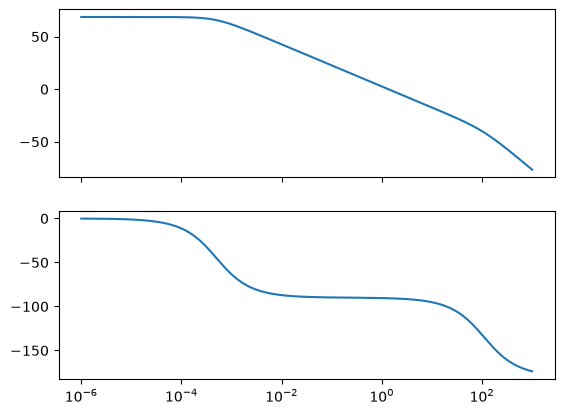

In [69]:
A = 10**(100 / 20)
GBW = 1e6

def HFB(s):
    return AFB / (1 + s * RTH * CTH)

def H(s):
    return A / (1 + s / (2 * np.pi * GBW / A))

f = np.logspace(-6, 3, 1000)
s = 1j * 2 * np.pi * f

y = H(s) / (1 + H(s) * HFB(s))

A2 = 10**(80 / 20)
open_loop = HFB(s) * (H(s) / (1 + H(s) / A2))

# phase margin
idx = np.argmin((20 * np.log10(np.abs(open_loop)) - 0) ** 2)
print(f"Unity gain frequency: {f[idx]:.2f} Hz")
print(f"Phase margin: {np.angle(open_loop[idx], deg=True) + 180:.2f} deg (> 60 deg)")

# gain margin
idx = np.argmin((np.angle(open_loop, deg=True) + 180) ** 2)
print(f"Gain margin: {20 * np.log10(np.abs(open_loop[idx])):.2f} dB (< 0 dB)")

fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].semilogx(f, 20 * np.log10(np.abs(open_loop)))
ax[1].semilogx(f, np.angle(open_loop, deg=True))

In [68]:
A2 - 1

9999.0